<table align="left" style="border-style: hidden" class="table"> <tr><td class="col-md-2"><img style="float: left; width: 200px; height: 200px;" src="../logo.png" alt="Data 140 Logo" style="width: 120px;"/></td><td><div align="left"><h3 style="margin-top: 0;">Probability for Data Science</h3><h4 style="margin-top: 20px;">UC Berkeley, Spring 2026</h4><p>Ani Adhikari</p>CC BY-NC-SA 4.0</div></td></tr></table><!-- not in pdf -->

This content is protected and may not be shared, uploaded, or distributed.

# Homework 7 (Due March 9th at 5 PM) #

In [1]:
import warnings
warnings.filterwarnings('ignore')

from prob140 import *
from datascience import *
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib
matplotlib.style.use('fivethirtyeight')

### Instructions

#### **Questions 1, 2, and 3 can be answered based on Tuesday's lecture (and past content) alone.** ####

Your homeworks will generally have two components: a written portion and a portion that also involves code.  Written work should be completed on paper, and coding questions should be done in the notebook. Start the work for the written portions of each section on a new page. You are welcome to $\LaTeX$ your answers to the written portions, but staff will not be able to assist you with $\LaTeX$ related issues. 

It is your responsibility to ensure that both components of the homework are submitted completely and properly to Gradescope. **Make sure to assign each page of your pdf to the correct question. Refer to the bottom of the notebook for submission instructions.**

### How to Do Your Homework ###
The point of homework is for you to try your hand at using what you've learned in class. The steps to follow:

- Go to lecture and sections, and also go over the relevant text sections before starting on the homework. This will remind you what was covered in class, and the text will typically contain examples not covered in lecture. The weekly Study Guide will list what you should read.
- Work on some of the practice problems before starting on the homework.
- Attempt the homework problems by yourself with the text, section work, and practice materials all at hand. Sometimes the week's lab will help as well. The two steps above will help this step go faster and be more fruitful.
- At this point, seek help if you need it. Don't ask how to do the problem — ask how to get started, or for a nudge to get you past where you are stuck. Always say what you have already tried. That helps us help you more effectively.
- For a good measure of your understanding, keep track of the fraction of the homework you can do by yourself or with minimal help. It's a better measure than your homework score, and only you can measure it.

### Rules for Homework ###
- Every answer should contain a calculation or reasoning. For example, a calculation such as $(1/3)(0.8) + (2/3)(0.7)$ or `sum([(1/3)*0.8, (2/3)*0.7])`is fine without further explanation or simplification. If we want you to simplify, we'll ask you to. But just ${5 \choose 2}$ by itself is not fine; write "we want any 2 out of the 5 frogs and they can appear in any order" or whatever reasoning you used. Reasoning can be brief and abbreviated, e.g. "product rule" or "not mutually exclusive."
- You may consult others (see "How to Do Your Homework" above) but you must write up your own answers using your own words, notation, and sequence of steps.
- We'll be using Gradescope. You must submit the homework according to the instructions at the end of homework set.

## **We will not grade assignments which do not have pages selected for each question.** ##

\newpage

## 1. Correlation ##
The *correlation coefficient* between random variables $X$ and $Y$ is defined as

$$
r(X, Y) ~ = \frac{Cov(X, Y)}{SD(X)SD(Y)}
$$

It is called the correlation, for short. The definition explains why $X$ and $Y$ are called *uncorrelated* if $Cov(X, Y) = 0$.

**a)** Let $X^*$ be $X$ in standard units and let $Y^*$ be $Y$ in standard units. Check that

$$
r(X, Y) = E(X^*Y^*)
$$

This is the random variable version of the Data 8 definition of the correlation between two data variables: convert each variable to standard units; multiply each pair; take the mean of the products.

**b)** Use the fact that $(X^* + Y^*)^2$ and $(X^* - Y^*)^2$ are non-negative random variables to show that $-1 \le r(X, Y) \le 1$.

[First find the numerical values of $E(X^*)$ and $E\left({X^*}^2\right)$. Then find $E\left((X^* + Y^*)^2\right)$.]

**c)** Show that if $Y = aX+b$ where $a \ne 0$, then $r(X, Y)$ is 1 or $-1$ depending on whether the sign of $a$ is positive or negative.

**d)** Consider a sequence of i.i.d. Bernoulli $(p)$ trials. For any positive integer $k$ let $X_k$ be the number of successes in trials 1 through $k$. **Use bilinearity** to find $Cov(X_n, X_{n+m})$ and hence find $r(X_n, X_{n+m})$.

**e)** Fix $n$ and find the limit of $r(X_n, X_{n+m})$ as $m \to \infty$. Explain why the limit is consistent with intuition.

**a)**
$$
\begin{aligned}
E(X^* Y^*) 
&= E\left( \frac{X - \mu_X}{\text{SD}(X)} \cdot \frac{Y - \mu_Y}{\text{SD}(Y)} \right) \\
&= \frac{E((X - \mu_X)(Y - \mu_Y))}{\text{SD}(X)\text{SD}(Y)} \\
&= \frac{\text{Cov}(X, Y)}{\text{SD}(X)\text{SD}(Y)} \\
&= r(X, Y)
\end{aligned}
$$

**b)**
$$
E(X^*) = E\left(\frac{X - \mu_X}{\text{SD}(X)}\right) = 0
$$
$$
\text{Var}(X^*) = \text{Var}\left(\frac{X - \mu_X}{\text{SD}(X)}\right) = \frac{\text{Var}(X)}{\text{SD}(X)^2} = \frac{\sigma_X^2}{\sigma_X^2} = 1
$$
由 $\text{Var}(X^*) = E({X^*}^2) - (E(X^*))^2 = 1$，可得：
$$
E({X^*}^2) = 1
$$
同理：
$$
E({Y^*}^2) = 1
$$

因为 $(X^* + Y^*)^2 \ge 0$，其期望非负：
$$
\begin{aligned}
E((X^* + Y^*)^2) = E({X^*}^2) + E({Y^*}^2) + 2E(X^*Y^*) &\ge 0 \\
1 + 1 + 2r &\ge 0 \\
2r &\ge -2 \\
r &\ge -1
\end{aligned}
$$

同理，因为 $(X^* - Y^*)^2 \ge 0$：
$$
\begin{aligned}
E((X^* - Y^*)^2) = E({X^*}^2) + E({Y^*}^2) - 2E(X^*Y^*) &\ge 0 \\
1 + 1 - 2r &\ge 0 \\
2r &\le 2 \\
r &\le 1
\end{aligned}
$$
综合可得 $-1 \le r(X, Y) \le 1$。证毕。

**c)**
若 $Y = aX + b$（$a \ne 0$），则 $\mu_Y = a\mu_X + b$，且 $\text{SD}(Y) = |a|\text{SD}(X)$。
$$
\begin{aligned}
r(X, Y) = E(X^* Y^*) 
&= E\left( \frac{X - \mu_X}{\text{SD}(X)} \cdot \frac{(aX + b) - (a\mu_X + b)}{|a|\text{SD}(X)} \right) \\
&= E\left( \frac{X - \mu_X}{\text{SD}(X)} \cdot \frac{a(X - \mu_X)}{|a|\text{SD}(X)} \right) \\
&= E\left( \frac{a}{|a|} {X^*}^2 \right) \\
&= \frac{a}{|a|} E({X^*}^2) \\
&= \frac{a}{|a|} \quad (\text{因为 } E({X^*}^2) = 1)
\end{aligned}
$$
当 $a > 0$ 时，$\frac{a}{|a|} = 1$；当 $a < 0$ 时，$\frac{a}{|a|} = -1$。
所以 $r(X, Y)$ 为 $1$ 或 $-1$，取决于 $a$ 的符号。

**d)**
令 $I_i$ 为第 $i$ 次试验是否成功的示性变量（$I_i \sim \text{Bernoulli}(p)$，各 $I_i$ 相互独立）。
则 $X_n = \sum_{i=1}^n I_i$，$X_{n+m} = \sum_{j=1}^{n+m} I_j$。

利用协方差的双线性性质（Bilinearity）：
$$
\begin{aligned}
\text{Cov}(X_n, X_{n+m}) 
&= \text{Cov}\left( \sum_{i=1}^n I_i, \sum_{j=1}^{n+m} I_j \right) \\
&= \sum_{i=1}^n \sum_{j=1}^{n+m} \text{Cov}(I_i, I_j)
\end{aligned}
$$
因为各次试验相互独立，当 $i \ne j$ 时 $\text{Cov}(I_i, I_j) = 0$；只有当 $i = j$（即 $j \le n$ 且 $j = i$）时协方差非零：
$$
\text{Cov}(I_i, I_i) = \text{Var}(I_i) = p(1-p)
$$
因此：
$$
\text{Cov}(X_n, X_{n+m}) = \sum_{i=1}^n \text{Var}(I_i) = \text{Var}(X_n) = np(1-p)
$$
进而：
$$
\begin{aligned}
r(X_n, X_{n+m}) 
&= \frac{\text{Cov}(X_n, X_{n+m})}{\text{SD}(X_n)\text{SD}(X_{n+m})} \\
&= \frac{\text{Var}(X_n)}{\text{SD}(X_n)\text{SD}(X_{n+m})} \\
&= \frac{np(1-p)}{\sqrt{np(1-p)} \sqrt{(n+m)p(1-p)}} \\
&= \sqrt{\frac{n}{n+m}}
\end{aligned}
$$

**e)**
当 $m \to \infty$ 时：
$$
\lim_{m \to \infty} r(X_n, X_{n+m}) = \lim_{m \to \infty} \sqrt{\frac{n}{n+m}} = 0
$$

直观解释：
当投掷次数非常大（$m \to \infty$）时，总成功次数几乎完全由后续大量的试验决定，前 $n$ 次固定投掷的成功次数在总成功次数中所占的比重趋近于 0。因此前 $n$ 次的试验结果对于总成功次数几乎不提供任何线性预测信息，相关系数趋近于 0，这与直觉一致（类似于马尔可夫链中长期来看逐渐遗忘初始状态的性质）。

\newpage

## 2. Collecting Distinct Values ##

In Homework 4 you found the expectation of each of the random variables below. **Go back and see how you did that, and then use the same ideas** to find the variance of each one. 

For one part you will need the fact that the SD of a geometric $(p)$ random variable is $\frac{\sqrt{q}}{p}$ where $q = 1-p$. We haven't proved that as the algebra takes a bit of work. We will prove it later in the course by conditioning.

**(a)** A die is rolled $n$ times. Find the variance of number of faces that *do not* appear.

**(b)** Use your answer to (a) to find the variance of the number of distinct faces that *do* appear in $n$ rolls of a die.

**(c)** Find the variance of the number of times you have to roll a die till you have seen all of the faces.

a)
M: number of missing faces
$$
M = I_1 + I_2 + \dots + I_6
$$
where for each j, $I_j$ is the indicator of “face j is missing in the sample”.

他们都是同分布的, 通过对称性, 也就是说 Cov(I_i, I_j) = Cov(I_1, I_2)

$$
Var(M) 
= 
Var(I_1 + \dots + I_6)
= 
\sum_{i=1}^{6} \mathrm{Var}(I_i) + 2 \sum_{i=1}^{5} \sum_{j=i+1}^{6} \mathrm{Cov}(I_i, I_j)
=
\sum_{i=1}^{6} \mathrm{Var}(I_1) + 30 \mathrm{Cov} (I_1, I_2)
=
6 \times (\frac{5}{6})^n (1- (\frac{5}{6})^n) + 30 \times ( (\frac{4}{6})^n - (\frac{5}{6})^{2n} )
$$

b)
N: 出现的不同面数
$$
N = 6-M
$$

$$
Var(N) 
=
Var(6-M)
=
Var(6) + Var(-M) + 2Cov(6, -M)
=
Var(M)
$$

c)
设 T 为见过 6 种面, 所需要的次数
t_i 为已经见过 i-1 种面, 见到第 i 种面所需要的次数

对于 t_i 来说: 见到新面的概率是: $\frac{6-(i-1)}{6}$

因此, 对于 t_i 来说, 符合期望为 $\frac{6}{6-i+1}$ 的几何分布

那么需要见到全部的面的次数 T_6 可以表示为: $t_1 + \dots t_6$

而且对于 t_i 来说, 他们是独立的随机变量, 可以用条将概率来判断
设 k_i 是某一个次数
$$
P(t_i = k_i \mid t_1 = k_j, t_2=k_m, \dots) = P(t_i=k_i) 
$$
对于 t_i 来说, 剩下的面数肯定是 (6-(i-1)) 个面, 然后进行有放回抽取, 所以抽取次数不会因为前面的抽取次数而有所改变

$$
Var(T_6) 
=
Var(t_1 + \dots + t_6) 
=
\sum_{i=1}^{6} \mathrm{Var}(t_i)
=
\sum_{i=1}^{6} (\frac{\sqrt{q_i}}{p_i})^2 
$$

将 i 带入即可

\newpage

## 3. The "Sample Variance" ###

Let $X_1, X_2, \ldots, X_n$ be i.i.d. (discrete or continuous), each with mean $\mu$ and SD $\sigma$. Let $\bar{X} = \frac{1}{n}\sum_{i=1}^n X_i$ be the sample mean.

**(a)** Find $E(\bar{X})$ and $SD(\bar{X})$. It's fine to just quote answers derived in class or in the textbook.

**(b)** For each $i$, find $Cov(X_i, \bar{X})$. [Plug in the definition of $\bar{X}$ and use bilinearity.]

**(c)** For each $i$ in the range 1 through $n$, define the *$i$th deviation in the sample* as $D_i = X_i - \bar{X}$. Find $E(D_i)$ and $Var(D_i)$. [Write the variance as $Cov(D_i, D_i)$, plug in the definition of $D_i$, and use bilinearity.]

**(d)** Define the random variable $\hat{\sigma}^2$ as
$$
\hat{\sigma}^2 ~ = ~ \frac{1}{n} \sum_{i=1}^n D_i^2
$$
Find $E(\hat{\sigma}^2)$.

For this random variable, the notation $\hat{\sigma}^2$ is pretty standard in statistics. Just think of $\hat{\sigma}^2$ as a symbol; it doesn't help to start thinking about the random variable that is its square root.

**(e)** Use Part **d** to construct a random variable denoted $S^2$ that is an unbiased estimator of $\sigma^2$. This random variable $S^2$ is called the *sample variance* and is frequently used in inference.

a)
$$
E(\bar{X})
=
\mu
$$

$$
Var(\bar{X}) 
=
\frac{1}{n^2} \sum_{i=1}^{n} {Var(X_i)}
=
\frac{1}{n^2} \sum_{i=1}^{n} \sigma^2
=
\frac{\sigma^2}{n}
$$

$$
SD(\bar{X})
=
\frac{\sigma}{\sqrt{n}}
$$



b)
$$
Cov(X_i, \bar{X})
=
Cov(X_i, \frac{1}{n}\sum_{i=1}^{n} {X_i})
=
Cov(X_i, \frac{1}{n} X_i)
=
\frac{1}{n} Var(X_i)
=
\frac{1}{n} \sigma^2
$$



c)
$$
E(D_i)
=
E(X_i - \bar{X})
=
E(X_i) - E(\bar{X})
=
0
$$

$$
\mathrm{Var}(D_i)
=
\mathrm{Cov}(D_i, D_i)
=
Cov(X_i - \bar{X}, X_i - \bar{X})
=
Var(X_i) - 2Cov(X_i, \bar{X}) + Var(\bar{X})
=
\sigma^2 - \frac{2}{n} \sigma^2 + \frac{\sigma^2}{n}
=
\sigma^2(\frac{n-1}{n})
$$

d)
$$
E( (D_i)^2 )
=
Var(D_i) + ( E(D_i))^2 
=
\frac{n-1}{n} \sigma^2
$$

$$
E(\hat{\sigma}^2) 
=
\frac{1}{n} \sum_{i=1}^{n} E( (D_i)^2 )
=
E( (D_i)^2)
=
\frac{n-1}{n} \sigma^2
$$

e)
$$
E(S^2)
=
\sigma^2
$$

$$
S^2 
=
\frac{1}{n-1} \sum_{i=1}^n D_i^2
$$

$$
\begin{aligned}
E(S^2) 
&= \frac{1}{n-1} \sum_{i=1}^{n} E(D_i^2) \\
&= \frac{1}{n-1} \cdot n \cdot \frac{n-1}{n} \sigma^2 \\
&= \sigma^2
\end{aligned}
$$

\newpage

## 4. Poisson-Binomial Distribution

For this exercise, please refer to the theory in [Section 14.1](https://data140.org/textbook/content/chapter-14/exact-distribution-of-a-sum/) and the code in [Section 14.2](https://data140.org/textbook/content/chapter-14/pgfs-in-numpy/).

In Lab 3B you saw that a *Poisson-binomial* random variable is a sum of independent indicators that are not necessarily identically distributed: 

$X = I_1 + I_2 + \cdots + I_n$ where $I_j$ has the Bernoulli $(p_j)$ distribution and $I_1, I_2, \ldots, I_n$ are independent.

**(a)** What is the probability generating function of a Bernoulli $(p)$ random variable? Provide a formula and then use the code cell below to define a function `indicator_pgf` that takes $p$ as its argument and returns the probability generating function of a Bernoulli $(p)$ random variable as a `NumPy` polynomial. Use as many lines as you need. The last line of the cell is there for you to check that your function is working.

px, 1-p

In [2]:

# Answer to a
def indicator_pgf(p):
    return np.poly1d(make_array(p, 1-p))
    
print(indicator_pgf(0.4))

 
0.4 x + 0.6



**(b)** For $j = 1, 2, \ldots, 20$, let $p_j = 1/(j+1)$. Let $I_1, I_2, \ldots, I_{20}$ be independent indicators such that $I_j$ has the Bernoulli $(p_j)$ distribution, and let $X = I_1 + I_2 + \cdots + I_{20}$. Complete the code cell below so that `pgf_X` is the probability generating function of $X$ as a `NumPy` polynomial. Use as many lines as you need. The last two lines are there for you to check that your polynomial has the correct degree and that it is indeed a probability generating function.

In [3]:
print(np.arange(1, 4))

[1 2 3]


In [4]:
p_j = 1/np.arange(2, 22)
p_j

array([ 0.5       ,  0.33333333,  0.25      ,  0.2       ,  0.16666667,
        0.14285714,  0.125     ,  0.11111111,  0.1       ,  0.09090909,
        0.08333333,  0.07692308,  0.07142857,  0.06666667,  0.0625    ,
        0.05882353,  0.05555556,  0.05263158,  0.05      ,  0.04761905])

In [5]:
pgf_X = indicator_pgf(p_j[0])
pgf_X

poly1d([ 0.5,  0.5])

In [6]:
# Answer to b

for p in p_j[1:]:
    curr_pgf = indicator_pgf(p)
    pgf_X *= curr_pgf
    
print(pgf_X)
sum(pgf_X.c) # sum of coefficients

           20            19             18            17             16
1.957e-20 x  + 4.11e-18 x  + 4.035e-16 x  + 2.46e-14 x  + 1.044e-12 x 
              15             14            13             12
 + 3.273e-11 x  + 7.863e-10 x  + 1.48e-08 x  + 2.214e-07 x 
              11             10             9            8            7
 + 2.654e-06 x  + 2.559e-05 x  + 0.0001985 x + 0.001234 x + 0.006094 x
            6           5          4          3          2
 + 0.02362 x + 0.07046 x + 0.1573 x + 0.2519 x + 0.2702 x + 0.1713 x + 0.04762


1.0000000000000002


**(c)** Complete the cell below to plot the probability histogram of $X$. Do not add any more lines.

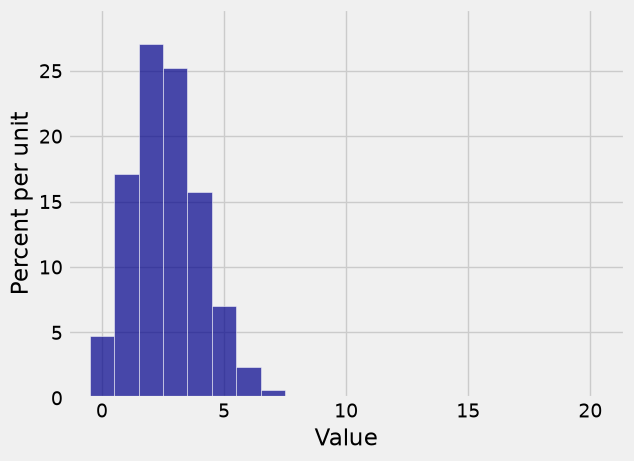

In [7]:
# Answer to c

vals_X = np.arange(21)
probs_X = np.flipud(pgf_X.c)
dist_X = Table().values(vals_X).probabilities(probs_X)
Plot(dist_X)


**(d)** Complete the cell below to find the expectation, variance, and SD of $X$ using `p_array`. Do not add any more lines. Then run the cell below that to check your answers.

In [8]:
p_array = 1/np.arange(2, 22)

In [9]:
p_array * (1-p_array)

array([ 0.25      ,  0.22222222,  0.1875    ,  0.16      ,  0.13888889,
        0.12244898,  0.109375  ,  0.09876543,  0.09      ,  0.08264463,
        0.07638889,  0.07100592,  0.06632653,  0.06222222,  0.05859375,
        0.05536332,  0.05246914,  0.0498615 ,  0.0475    ,  0.04535147])

In [10]:
np.sum(p_array * (1-p_array))

2.046927887153561

In [11]:
# Answer to d


ev_X = np.sum(p_array)
var_X = np.sum(p_array * (1-p_array))
sd_X = np.sqrt(var_X)
ev_X, var_X, sd_X

(2.6453587047627294, 2.046927887153561, 1.4307088757513042)

In [12]:
dist_X.ev(), dist_X.var(), dist_X.sd()

(2.6453587047627281, 2.0469278871535597, 1.4307088757513038)


**(e)** Explain why the distribution of $X$ cannot be Poisson. Then show that the distribution of $X$ is not binomial either, as follows. If $X$ were binomial, what would $n$ have to be? Use that and your answer to Part (d) to see what $p$ would have to be. Use the code cell below to find the variance of that binomial distribution, and compare with your answer to Part (d).

X 不是同分布的实验

因为每次成功的概率都不一样, 因此 X 的分布也不是二项分布

n 必须是实验的次数
p 必须是一次实验的成功率

In [13]:
# Answer to e

n = 20
p = np.mean(p_array)
binomial_variance = n*p*(1-p) 
binomial_variance

2.2954625709195318

\newpage


## 5. Testing Hypotheses in the Gauss Model

The [Gauss](https://en.wikipedia.org/wiki/Carl_Friedrich_Gauss) model for measurement error says that repeated measurements $X_1, X_2, \ldots, X_n$ of the same quantity have the structure

$$
X_i = \mu + \epsilon_i, ~~~~~ 1 \leq i \leq n
$$

where $\mu$ is an unknown constant called the *true value* and $\epsilon_1, \epsilon_2, \ldots, \epsilon_n$ are random error terms assumed to be i.i.d. with mean 0 and variance $\sigma^2$. 

From a practical perspective, the true value $\mu$ comes from the quantity being measured (for example, the true weight of an object). The error terms come from the measuring process (for example, from the balance being used for weighing). Thus $\sigma$ is sometimes known because of extensive experience with the measuring process (for example, having used the same balance to weigh many different objects). 

So assume that the Gauss model holds with $\sigma = 1$, and let $n = 100$. Suppose a data scientist wants to test the following hypotheses:

- Null hypothesis $H_0$: $\mu = 20$
- Alternative hypothesis $H_A$: $\mu \neq 20$

Suppose the data scientist wants to use the average measurement $\bar{X}$ as the test statistic and reject the null hypothesis if $\vert \bar{X} - 20 \vert > 0.175$.

**(a)** Rewrite the decision rule by filling in the blanks with numbers: $\vert \bar{X} - 20 \vert > 0.175 \iff \bar{X} < \underline{~~~~~~~~} \text{ or } \bar{X} > \underline{~~~~~~~~}$

**(b) Level:** Find the approximate distribution of the test statistic $\bar{X}$ under $H_0$, and use this distribution to find the approximate probability that the test rejects the null hypothesis if the null hypothesis is true. This probability is called the *level* of the test. In Data 8 we called it the cutoff for the p-value. 

**Please write out your answer in math notation.** Then use the code cell below for scratch work. Remember that `stats.norm.cdf(x, mean, SD)` evaluates to the cdf of the normal $(\text{mean, } \text{SD}^2)$ distribution at the point $x$. The necessary modules have been imported at the top of this notebook.

**(c) Power:** Suppose that in fact $\mu = 20.5$ though the data scientist doesn't know this and is still performing the same test as above. Find the approximate distribution of the test statistic $\bar{X}$ under the condition $\mu = 20.5$, and use this distribution to find the approximate probability that the test rejects the null hypothesis if $\mu = 20.5$. This probability is called the *power of the test against the fixed alternative $\mu = 20.5$*. 

**Please write out your answer in math notation.** Then use the code cell below for scratch work.

a)
$$
\bar{X} < 19.825
$$
$$
\bar{X} > 20.175
$$

b)
在 H_0 之下, 
$$
E(X_i) = \mu = 20
Var(X_i) = Var(\epsilon_i) = \sigma^2 = 1
$$

根据中心极限定理: 当 n 很大时, 和的分布近似服从正态分布
$$
E(\bar{X}) = \frac{1}{n} \sum_{i=1}^{n} X_i = 20
$$

同一物体的不同测量之间是独立事件, 因此
$$
Var(\bar{X})
=
Var(\frac{1}{n} \sum_{i=1}^{100}X_i)
=
\frac{1}{n^2} \sum_{i=1}^{100}Var(X_i)
=
\frac{1}{n^2} n \cdot 1
=
\frac{1}{n}
$$

$$
SD(\bar{X})
=
\frac{1}{10}
$$

因此 $\bar{X}$ 服从 normal(20, 0.1)

设 A 为原假设为真, B 为拒绝原假设, 则在原假设为真时, 拒绝原假设: $P(B \mid A) = 0.08$

c)
同样的
$$
E(\bar{X})
= 
\mu
=
20.5
$$

$$
Var(\bar{X}) 
=
\frac{1}{100}
$$

$$
SD(\bar{X})
=
\frac{1}{10}
$$

拒绝原假设的概率为 0.999

In [30]:
# Scratch work for b and c
1 - (stats.norm.cdf(20.175, 20, 0.1) - stats.norm.cdf(19.825, 20, 0.1))

0.080118313727632895


**(d)** Complete the code cell below to plot the graph of the power of the test under the fixed alternative $\mu = \mu_A$ for $\mu_A$ in the range `true_mu` below. Do not add any more lines.

Computational note: First study the code below and compare with the output of the cell. 

In [21]:
mu_list = [10, 15, 20]  # It's also fine for this to be an array.

# array of P(X_i < 12)
# for X_i normal with mean = ith element of mu_list
# and SD = 8
stats.norm.cdf(12, mu_list, 8)

array([ 0.59870633,  0.35383023,  0.15865525])

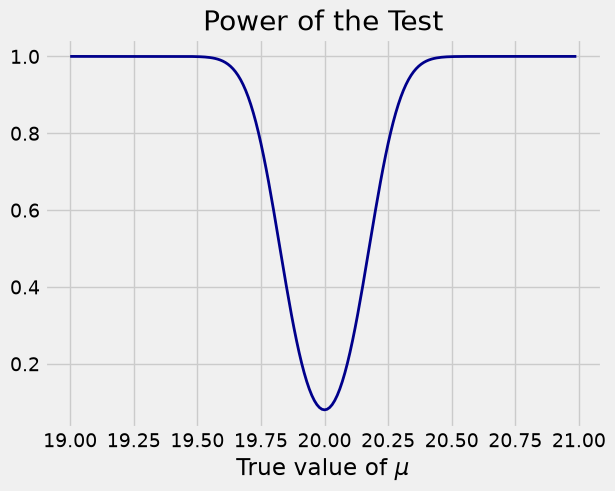

In [29]:
# Answer to d

true_mu = np.arange(19, 21, 0.01)
power = 1-(stats.norm.cdf(20.175, true_mu, 0.1) - stats.norm.cdf(19.825, true_mu, 0.1))

plt.plot(true_mu, power, color='darkblue', lw=2)
plt.xlabel(r'True value of $\mu$')
plt.title('Power of the Test');


**(e)** Interpret the graph. What is the test likely to do if the true value of $\mu$ is far from 20, and what does the power converge to (be careful!) when the true value gets close to $20$?

拒绝原假设

接近于 0.08

## Submission Instructions ##

Many assignments throughout the course will have a written portion and a code portion. Please follow the directions below to properly submit both portions.

### Written Portion ###
*  Scan all the pages into a PDF. You can use any scanner or a phone using applications such as CamScanner. Please **DO NOT** simply take pictures using your phone. 
* Please start a new page for each question. If you have already written multiple questions on the same page, you can crop the image in CamScanner or fold your page over (the old-fashioned way). This helps expedite grading.
* It is your responsibility to check that all the work on all the scanned pages is legible.
* If you used $\LaTeX$ to do the written portions, you do not need to do any scanning; you can just download the whole notebook as a PDF via LaTeX.

### Code Portion ###
* Save your notebook using `File > Save Notebook`.
* Generate a PDF file using `File > Save and Export Notebook As > PDF`. This might take a few seconds and will automatically download a PDF version of this notebook.
    * If you have issues, please post a follow-up on the general Homework 7 Ed thread.
    
### Submitting ###
* Combine the PDFs from the written and code portions into one PDF. [Here](https://smallpdf.com/merge-pdf) is a useful tool for doing so. 
* Submit the assignment to Homework 7 on Gradescope. 
* **Make sure to assign each page of your pdf to the correct question.**
* **It is your responsibility to verify that all of your work shows up in your final PDF submission.**

If you are having difficulties scanning, uploading, or submitting your work, please read the [Ed Thread](https://edstem.org/us/courses/94054/discussion/7533569) on this topic and post a follow-up on the general Homework 7 Ed thread.

## **We will not grade assignments which do not have pages selected for each question.** ##